In [1]:

import pandas as pd
import numpy as np

# Isto é para definir  semente para reprodutibilidade
np.random.seed(42)

n = 2000

genres = ['Action', 'Adventure', 'Platform', 'Puzzle', 'RPG', 'Shooter', 'Sports', 'Racing', 'Simulation']
platforms = ['PC', 'PS5', 'Xbox Series X', 'Switch', 'Mobile']
age_ratings = ['Livre', '10+', '14+', '18+']

# Definindo probabilidade de estilo de design por gênero (para que gere um padrão realista)
design_prob_by_genre = {
    'Platform': 0.85, 'Puzzle': 0.80, 'Adventure': 0.55,
    'RPG': 0.40, 'Simulation': 0.50, 'Action': 0.20,
    'Shooter': 0.10, 'Sports': 0.15, 'Racing': 0.25
}

rows = []
for i in range(n):
    genre = np.random.choice(genres)
    prob_2d = design_prob_by_genre[genre]
    design_type = np.random.choice(['2D', '3D'], p=[prob_2d, 1 - prob_2d])
    
    if design_type == '2D':
        age_rating = np.random.choice(age_ratings, p=[0.45, 0.30, 0.15, 0.10])
    else:
        age_rating = np.random.choice(age_ratings, p=[0.15, 0.30, 0.30, 0.25])
    
    platform = np.random.choice(platforms)
    release_year = np.random.randint(2015, 2025)
    
    base_sales = np.random.gamma(shape=2.0, scale=0.5)
    multiplier = 1.15 if design_type == '3D' else 1.0
    
    na_sales = round(base_sales * multiplier * np.random.uniform(0.3, 0.5), 2)
    eu_sales = round(base_sales * multiplier * np.random.uniform(0.2, 0.4), 2)
    jp_sales = round(base_sales * multiplier * np.random.uniform(0.05, 0.2), 2)
    other_sales = round(base_sales * multiplier * np.random.uniform(0.05, 0.15), 2)
    
    critic_score = round(np.random.normal(75, 10), 1)
    critic_score = min(max(critic_score, 20), 100)
    
    rows.append({
        'game_id': i + 1,
        'name': f'Game_{i+1}',
        'genre': genre,
        'platform': platform,
        'design_type': design_type,
        'age_rating': age_rating,
        'release_year': release_year,
        'na_sales': na_sales,
        'eu_sales': eu_sales,
        'jp_sales': jp_sales,
        'other_sales': other_sales,
        'critic_score': critic_score
    })

df = pd.DataFrame(rows)

# Introduzindo valores ausentes propositalmente (para a  prática de pré-processamento)
missing_idx = np.random.choice(df.index, size=40, replace=False)
df.loc[missing_idx, 'critic_score'] = np.nan

missing_idx2 = np.random.choice(df.index, size=15, replace=False)
df.loc[missing_idx2, 'age_rating'] = np.nan

# Introduzindo duplicatas propositalmente
df = pd.concat([df, df.sample(10, random_state=1)], ignore_index=True)

# Calculando vendas globais
df['global_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Salvando em CSV
df.to_csv('games_sales_dataset.csv', index=False)

print("Dataset criado com sucesso!")
print("Formato:", df.shape)
df.head()

Dataset criado com sucesso!
Formato: (2010, 13)


,game_id,name,genre,platform,design_type,age_rating,release_year,na_sales,eu_sales,jp_sales,other_sales,critic_score,global_sales
0,1,Game_1,Sports,Mobile,3D,10+,2019,0.38,0.25,0.12,0.04,72.7,0.79
1,2,Game_2,Adventure,PS5,3D,18+,2019,0.76,0.76,0.28,0.14,90.4,1.94
2,3,Game_3,Platform,PC,2D,18+,2017,0.34,0.44,0.15,0.10,83.3,1.03
3,4,Game_4,RPG,Switch,2D,Livre,2021,0.68,0.42,0.29,0.17,78.7,1.56
4,5,Game_5,Shooter,PS5,3D,10+,2024,0.14,0.12,0.05,0.05,79.7,0.36


# Pré-processamento de Dados

Nesta etapa, vamos verificar a qualidade dos dados: tipos de colunas, valores ausentes e duplicados, antes de seguir para a análise exploratória.

In [2]:
print("Informações gerais:")
print(df.info())

print("\nValores ausentes por coluna:")
print(df.isna().sum())

print("\nNúmero de linhas duplicadas:", df.duplicated().sum())

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2010 entries, 0 to 2009
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   game_id       2010 non-null   int64  
 1   name          2010 non-null   object 
 2   genre         2010 non-null   object 
 3   platform      2010 non-null   object 
 4   design_type   2010 non-null   object 
 5   age_rating    1995 non-null   object 
 6   release_year  2010 non-null   int64  
 7   na_sales      2010 non-null   float64
 8   eu_sales      2010 non-null   float64
 9   jp_sales      2010 non-null   float64
 10  other_sales   2010 non-null   float64
 11  critic_score  1970 non-null   float64
 12  global_sales  2010 non-null   float64
dtypes: float64(6), int64(2), object(5)
memory usage: 204.3+ KB
None

Valores ausentes por coluna:
game_id          0
name             0
genre            0
platform         0
design_type      0
age_rating      15
release_year   

### Observações — Qualidade dos Dados

- O dataset contém 2010 linhas e 13 colunas.
- Valores ausentes: 15 em `age_rating` e 40 em `critic_score`.
- Foram encontradas 10 linhas duplicadas.
- Os tipos de dados estão majoritariamente corretos (`int64` para IDs e ano, `float64` para vendas e nota, `object` para categorias), não sendo necessária conversão de tipos.

**Decisões de tratamento:**
- As linhas duplicadas serão removidas.
- Os valores ausentes em `age_rating` serão preenchidos com `"Desconhecido"`, já que representam uma pequena fração dos dados e não há como inferir a classificação etária real.
- Os valores ausentes em `critic_score` serão preenchidos com a mediana da coluna, para não distorcer a distribuição com outliers.

In [3]:
df = df.drop_duplicates().reset_index(drop=True)

df['age_rating'] = df['age_rating'].fillna('Desconhecido')
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())

print("Formato após limpeza:", df.shape)
print("\nValores ausentes após tratamento:")
print(df.isna().sum())
print("\nDuplicados após tratamento:", df.duplicated().sum())

Formato após limpeza: (2000, 13)

Valores ausentes após tratamento:
game_id         0
name            0
genre           0
platform        0
design_type     0
age_rating      0
release_year    0
na_sales        0
eu_sales        0
jp_sales        0
other_sales     0
critic_score    0
global_sales    0
dtype: int64

Duplicados após tratamento: 0


**Resultado do tratamento:** após remoção de duplicatas e preenchimento de valores ausentes, o dataset ficou com **2000 linhas**, sem nenhum valor ausente ou duplicado — pronto para a etapa de Análise Exploratória de Dados.

# Análise Exploratória de Dados (EDA)

Nesta etapa, vamos explorar as principais distribuições dos dados: estilo de design, vendas por estilo, faixa etária e vendas por região.

Distribuição de jogos por estilo de design:
3D    1165
2D     835
Name: design_type, dtype: int64


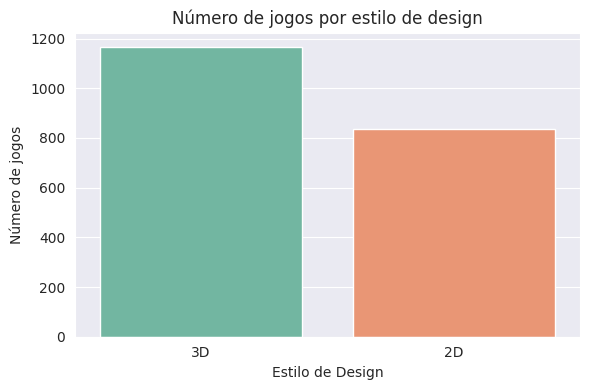

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

# Distribuição de jogos por estilo de design
design_counts = df['design_type'].value_counts()
print("Distribuição de jogos por estilo de design:")
print(design_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='design_type', palette='Set2')
plt.title('Número de jogos por estilo de design')
plt.xlabel('Estilo de Design')
plt.ylabel('Número de jogos')
plt.tight_layout()
plt.show()

### Observações — Distribuição por Estilo de Design

O dataset contém **1165 jogos 3D (58,25%)** e **835 jogos 2D (41,75%)**. Há uma maioria de jogos 3D no catálogo, mas ambos os estilos possuem representatividade suficiente para comparações estatísticas robustas.

Vendas globais por estilo de design:
                 sum      mean  median  count
design_type                                  
2D            773.75  0.926647    0.78    835
3D           1261.43  1.082773    0.92   1165


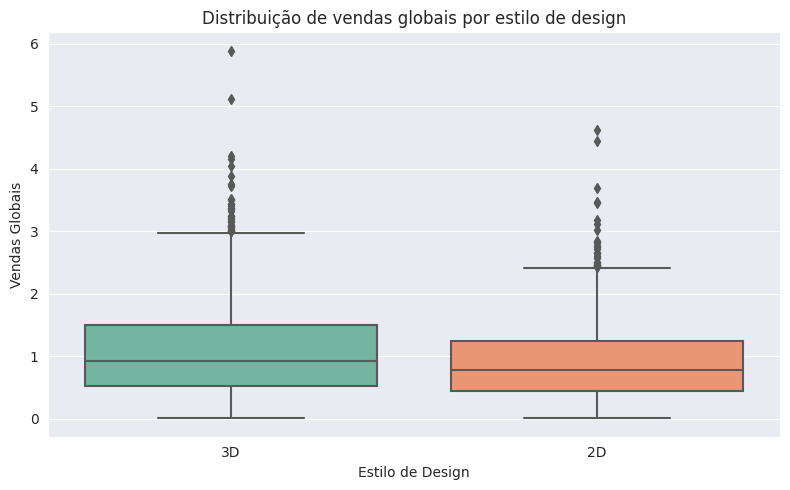

In [5]:
# Distribuição de vendas globais por estilo de design
sales_by_design = df.groupby('design_type')['global_sales'].agg(['sum', 'mean', 'median', 'count'])
print("Vendas globais por estilo de design:")
print(sales_by_design)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='design_type', y='global_sales', palette='Set2')
plt.title('Distribuição de vendas globais por estilo de design')
plt.xlabel('Estilo de Design')
plt.ylabel('Vendas Globais')
plt.tight_layout()
plt.show()

### Observações — Vendas por Estilo de Design

| Estilo | Soma total | Média | Mediana | Nº de jogos |
|---|---|---|---|---|
| 2D | 773,75 | 0,927 | 0,78 | 835 |
| 3D | 1.261,43 | 1,083 | 0,92 | 1.165 |

Jogos 3D apresentam vendas médias e medianas superiores aos jogos 2D, o que é um primeiro indício visual a favor da Hipótese 1 (H1: jogos 3D vendem mais que jogos 2D em média). Essa diferença será validada estatisticamente na próxima etapa (teste de hipótese).

Distribuição de jogos por faixa etária:
10+             589
Livre           561
14+             485
18+             350
Desconhecido     15
Name: age_rating, dtype: int64


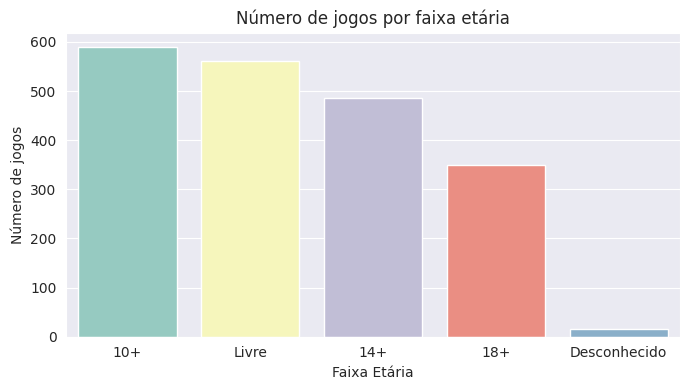

In [6]:
# Distribuição de jogos por faixa etária
age_counts = df['age_rating'].value_counts()
print("Distribuição de jogos por faixa etária:")
print(age_counts)

plt.figure(figsize=(7,4))
sns.countplot(data=df, x='age_rating', order=age_counts.index, palette='Set3')
plt.title('Número de jogos por faixa etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de jogos')
plt.tight_layout()
plt.show()

### Observações — Distribuição por Faixa Etária

| Faixa Etária | Nº de jogos |
|---|---|
| 10+ | 589 |
| Livre | 561 |
| 14+ | 485 |
| 18+ | 350 |
| Desconhecido | 15 |

A distribuição está relativamente equilibrada entre as faixas etárias, com destaque para "10+" e "Livre" como as mais numerosas — o que é coerente, já que jogos voltados para público infantil/família tendem a ser mais numerosos no mercado. A categoria "Desconhecido" (valores ausentes tratados) representa uma fração muito pequena (15 jogos, 0,75%) e não deve impactar significativamente as análises.

Vendas totais por região:
América do Norte    881.45
Europa              661.18
Japão               275.66
Outras Regiões      216.89
dtype: float64


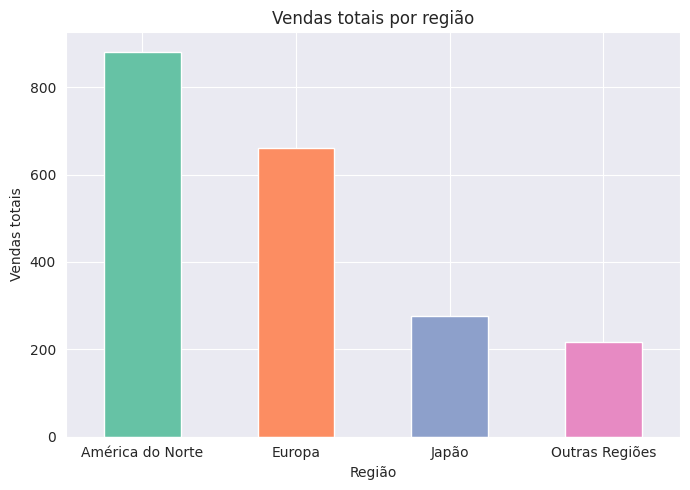

In [7]:
# Distribuição de vendas totais por região (com nomes legíveis)
region_names = {
    'na_sales': 'América do Norte',
    'eu_sales': 'Europa',
    'jp_sales': 'Japão',
    'other_sales': 'Outras Regiões'
}

sales_by_region = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
sales_by_region = sales_by_region.rename(index=region_names)

print("Vendas totais por região:")
print(sales_by_region)

plt.figure(figsize=(7,5))
sales_by_region.plot(kind='bar', color=sns.color_palette('Set2'))
plt.title('Vendas totais por região')
plt.xlabel('Região')
plt.ylabel('Vendas totais')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Observações — Vendas por Região

| Região | Vendas Totais |
|---|---|
| América do Norte | 881,45 |
| Europa | 661,18 |
| Japão | 275,66 |
| Outras Regiões | 216,89 |

A América do Norte é o mercado com maior volume de vendas, seguida pela Europa. Japão e Outras Regiões têm participação bem menor, o que é consistente com o padrão observado em mercados reais de games (concentração de vendas em NA e EU).

In [8]:
from scipy import stats

sales_2d = df[df['design_type'] == '2D']['global_sales']
sales_3d = df[df['design_type'] == '3D']['global_sales']

stat_2d, p_2d = stats.shapiro(sales_2d.sample(min(500, len(sales_2d)), random_state=42))
stat_3d, p_3d = stats.shapiro(sales_3d.sample(min(500, len(sales_3d)), random_state=42))

print(f"Shapiro-Wilk 2D: estatística={stat_2d:.4f}, p-value={p_2d:.4f}")
print(f"Shapiro-Wilk 3D: estatística={stat_3d:.4f}, p-value={p_3d:.4f}")
print("\nDistribuição normal?", "2D:", "Sim" if p_2d > 0.05 else "Não", "| 3D:", "Sim" if p_3d > 0.05 else "Não")

Shapiro-Wilk 2D: estatística=0.8885, p-value=0.0000
Shapiro-Wilk 3D: estatística=0.8984, p-value=0.0000

Distribuição normal? 2D: Não | 3D: Não


### Verificação de Normalidade

O teste de Shapiro-Wilk indicou que as distribuições de vendas globais de ambos os grupos **não seguem uma distribuição normal** (2D: p-value ≈ 0,0000 | 3D: p-value ≈ 0,0000). Isso é esperado, já que dados de vendas tipicamente apresentam assimetria à direita (poucos jogos com vendas muito altas). Por esse motivo, utilizamos o **teste de Mann-Whitney U**, que não exige o pressuposto de normalidade, para testar a Hipótese 1.

In [9]:
stat, p_value = stats.mannwhitneyu(sales_3d, sales_2d, alternative='greater')

alpha = 0.05

print(f"Estatística U: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print("\nH0: vendas médias de 3D = vendas médias de 2D")
print("Ha: vendas médias de 3D > vendas médias de 2D")
print("\nRejeitamos H0?", "Sim" if p_value < alpha else "Não")

Estatística U: 541356.0000
p-value: 0.000008

H0: vendas médias de 3D = vendas médias de 2D
Ha: vendas médias de 3D > vendas médias de 2D

Rejeitamos H0? Sim


### Resultado — Teste da Hipótese 1

**Teste de Mann-Whitney U:**
- Estatística U: 541.356,00
- p-value: 0,000008

Como o p-value (0,000008) é muito menor que α = 0,05, **rejeitamos H0**.

**Conclusão:** há evidência estatística forte de que jogos com design 3D vendem, em média, significativamente mais que jogos com design 2D. Isso confirma a **Hipótese 1 (Ha)**.

Vendas médias por faixa etária e estilo de design:
design_type         2D        3D
age_rating                      
10+           0.959383  1.152110
14+           0.882713  1.063848
18+           0.987561  1.061940
Desconhecido  0.620000  1.146000
Livre         0.915283  1.019684


<Figure size 900x500 with 0 Axes>

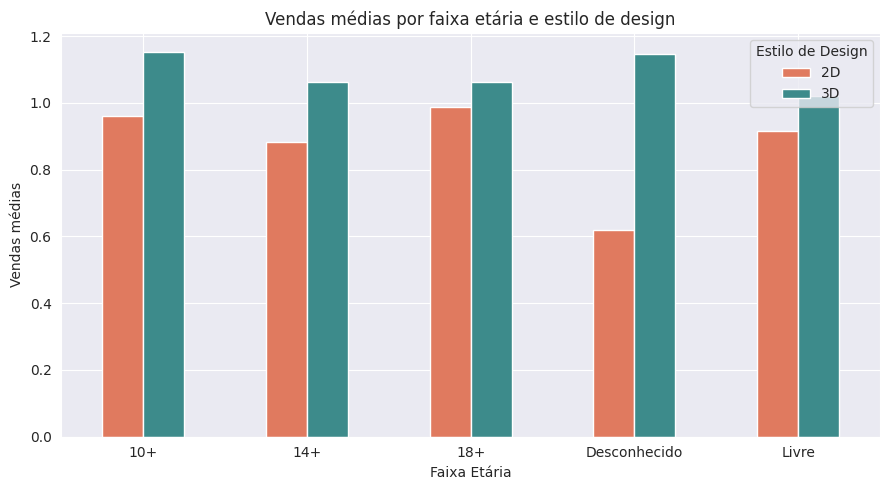

In [10]:
# Vendas médias por design e faixa etária
design_age_sales = df.groupby(['age_rating', 'design_type'])['global_sales'].mean().unstack()
print("Vendas médias por faixa etária e estilo de design:")
print(design_age_sales)

plt.figure(figsize=(9,5))
design_age_sales.plot(kind='bar', color=['#e07a5f', '#3d8b8b'], figsize=(9,5))
plt.title('Vendas médias por faixa etária e estilo de design')
plt.xlabel('Faixa Etária')
plt.ylabel('Vendas médias')
plt.xticks(rotation=0)
plt.legend(title='Estilo de Design')
plt.tight_layout()
plt.show()

### Observações — Vendas Médias por Faixa Etária e Estilo de Design

| Faixa Etária | 2D | 3D |
|---|---|---|
| 10+ | 0,959 | 1,152 |
| 14+ | 0,883 | 1,064 |
| 18+ | 0,988 | 1,062 |
| Livre | 0,915 | 1,020 |
| Desconhecido | 0,620 | 1,146 |

Em todas as faixas etárias, jogos 3D apresentam vendas médias superiores aos jogos 2D. A diferença entre estilos parece relativamente consistente entre as faixas (aproximadamente 0,1 a 0,2 de diferença), com exceção da faixa "Desconhecido" (baseada em poucos dados). Isso sugere, visualmente, que pode não haver uma forte interação entre design e faixa etária — a vantagem do 3D parece se manter proporcionalmente semelhante em quase todas as faixas.

In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_known_age = df[df['age_rating'] != 'Desconhecido']

model = ols('global_sales ~ C(design_type) + C(age_rating) + C(design_type):C(age_rating)', data=df_known_age).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Resultado da ANOVA de duas vias:")
print(anova_table)

Resultado da ANOVA de duas vias:
                                   sum_sq      df          F    PR(>F)
C(design_type)                   9.157893     1.0  17.707270  0.000027
C(age_rating)                    2.545664     3.0   1.640725  0.177954
C(design_type):C(age_rating)     0.967902     3.0   0.623830  0.599591
Residual                      1022.470075  1977.0        NaN       NaN


### Resultado — Teste da Hipótese 2

**ANOVA de duas vias:**

| Fonte | F | p-value |
|---|---|---|
| Estilo de Design | 17,71 | 0,000027 |
| Faixa Etária | 1,64 | 0,178 |
| Interação (Design × Faixa Etária) | 0,62 | 0,600 |

- O efeito principal do **estilo de design** é estatisticamente significativo (p < 0,05), confirmando novamente que 3D e 2D têm vendas médias diferentes (consistente com a Hipótese 1).
- O efeito principal da **faixa etária** não é estatisticamente significativo (p = 0,178).
- O termo de **interação** entre design e faixa etária **não é estatisticamente significativo** (p = 0,600), muito acima de α = 0,05.

**Conclusão:** **rejeitamos a hipótese alternativa (Ha) e não rejeitamos H0** para a Hipótese 2. Não há evidência estatística de que a diferença de vendas entre jogos 3D e 2D varie de acordo com a faixa etária do público. A vantagem de vendas do estilo 3D sobre o 2D se mantém proporcionalmente consistente em todas as faixas etárias analisadas.

In [12]:
df_known_age = df[df['age_rating'] != 'Desconhecido'].copy()
# Agora estou criando uma variável binária: público infantil (Livre) vs demais
df_known_age['is_child_audience'] = df_known_age['age_rating'] == 'Livre'

# Calculando proporção de jogos 2D dentro de cada grupo
prop_table = df_known_age.groupby('is_child_audience')['design_type'].value_counts(normalize=True).unstack()
print("Proporção de estilo de design por público (infantil vs demais):")
print(prop_table)

Proporção de estilo de design por público (infantil vs demais):
design_type              2D        3D
is_child_audience                    
False              0.318820  0.681180
True               0.661319  0.338681


### Observações — Proporção de Design por Público

| Público | 2D | 3D |
|---|---|---|
| Não-infantil | 31,88% | 68,12% |
| Infantil (Livre) | 66,13% | 33,87% |

A proporção de jogos 2D é substancialmente maior entre o público infantil (66,13%) do que entre os demais públicos (31,88%) — uma diferença de mais de 34 pontos percentuais. Isso é um forte indício de que jogos infantis tendem a adotar mais o estilo 2D. Vamos validar isso estatisticamente com o teste z de proporções.

In [13]:
from statsmodels.stats.proportion import proportions_ztest

child_2d = df_known_age[(df_known_age['is_child_audience'] == True) & (df_known_age['design_type'] == '2D')].shape[0]
child_total = df_known_age[df_known_age['is_child_audience'] == True].shape[0]

other_2d = df_known_age[(df_known_age['is_child_audience'] == False) & (df_known_age['design_type'] == '2D')].shape[0]
other_total = df_known_age[df_known_age['is_child_audience'] == False].shape[0]

success = [child_2d, other_2d]
nobs = [child_total, other_total]

stat, p_value = proportions_ztest(success, nobs, alternative='larger')

alpha = 0.05

print(f"z-stat: {stat:.4f}")
print(f"p-value: {p_value:.6f}")
print("\nH0: proporção de jogos 2D é igual entre público infantil e demais")
print("Ha: proporção de jogos 2D é maior entre o público infantil")
print("\nRejeitamos H0?", "Sim" if p_value < alpha else "Não")

z-stat: 13.9418
p-value: 0.000000

H0: proporção de jogos 2D é igual entre público infantil e demais
Ha: proporção de jogos 2D é maior entre o público infantil

Rejeitamos H0? Sim


### Resultado — Teste da Hipótese 3

**Teste Z de Proporções:**
- z-stat: 13,9418
- p-value: < 0,000001

Como o p-value é muito menor que α = 0,05, **rejeitamos H0**.

**Conclusão:** há evidência estatística muito forte de que a proporção de jogos 2D é significativamente maior entre o público infantil (classificação "Livre") em comparação aos demais públicos. Isso confirma a **Hipótese 3 (Ha)**.


# Métricas de Negócio e Indicadores (KPIs)

Nesta seção, calculamos os indicadores definidos na etapa de decomposição, com base nos resultados obtidos.

In [15]:
# KPI 1: (Participação de mercado por estilo de design) Market Share
total_sales = df['global_sales'].sum()
market_share = df.groupby('design_type')['global_sales'].sum() / total_sales * 100
print("KPI 1 — Participação de mercado por estilo de design (%):")
print(market_share)

# KPI 2: (Ticket médio de vendas por jogo, segmentado por estilo e região)
ticket_medio = df.groupby('design_type')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].mean()
ticket_medio = ticket_medio.rename(columns=region_names)
print("\nKPI 2 — Ticket médio de vendas por jogo, por estilo e região:")
print(ticket_medio)

# KPI 3: (Proporção de jogos por estilo dentro de cada faixa etária)
prop_estilo_faixa = df.groupby('age_rating')['design_type'].value_counts(normalize=True).unstack() * 100
print("\nKPI 3 — Proporção de jogos por estilo, dentro de cada faixa etária (%):")
print(prop_estilo_faixa)

# KPI 4: (Índice comparativo de desempenho) razão 3D/2D
media_3d = df[df['design_type'] == '3D']['global_sales'].mean()
media_2d = df[df['design_type'] == '2D']['global_sales'].mean()
indice_3d_2d = media_3d / media_2d
print(f"\nKPI 4 — Índice comparativo de desempenho (3D/2D): {indice_3d_2d:.4f}")
print("(Índice > 1 indica vantagem de vendas do 3D sobre o 2D)")

KPI 1 — Participação de mercado por estilo de design (%):
design_type
2D    38.01875
3D    61.98125
Name: global_sales, dtype: float64

KPI 2 — Ticket médio de vendas por jogo, por estilo e região:
             América do Norte    Europa     Japão  Outras Regiões
design_type                                                      
2D                   0.402192  0.300263  0.126120        0.098072
3D                   0.468343  0.352326  0.146223        0.115880

KPI 3 — Proporção de jogos por estilo, dentro de cada faixa etária (%):
design_type          2D         3D
age_rating                        
10+           41.256367  58.743633
14+           26.597938  73.402062
18+           23.428571  76.571429
Desconhecido  66.666667  33.333333
Livre         66.131907  33.868093

KPI 4 — Índice comparativo de desempenho (3D/2D): 1.1685
(Índice > 1 indica vantagem de vendas do 3D sobre o 2D)


### Resultados dos KPIs

**KPI 1 — Participação de mercado por estilo de design:**
- 2D: 38,02%
- 3D: 61,98%

Jogos 3D dominam quase 62% do mercado em volume de vendas, refletindo tanto sua maior representatividade no catálogo quanto suas vendas médias superiores.

**KPI 2 — Ticket médio de vendas por jogo, por estilo e região:**

| Região | 2D | 3D |
|---|---|---|
| América do Norte | 0,402 | 0,468 |
| Europa | 0,300 | 0,352 |
| Japão | 0,126 | 0,146 |
| Outras Regiões | 0,098 | 0,116 |

Em todas as regiões, o ticket médio de jogos 3D supera o de 2D, mantendo uma proporção relativamente constante entre regiões — reforçando que a vantagem do 3D é um padrão global, não específico de um mercado.

**KPI 3 — Proporção de jogos por estilo, dentro de cada faixa etária:**

| Faixa Etária | 2D | 3D |
|---|---|---|
| 10+ | 41,26% | 58,74% |
| 14+ | 26,60% | 73,40% |
| 18+ | 23,43% | 76,57% |
| Livre | 66,13% | 33,87% |

Fica evidente um padrão claro: quanto mais jovem o público-alvo, maior a proporção de jogos 2D no catálogo. O público "Livre" é o único em que o 2D é maioria (66,13%), enquanto a proporção de 3D cresce progressivamente até atingir 76,57% no público 18+.

**KPI 4 — Índice comparativo de desempenho (3D/2D):**

Índice = 1,1685

Jogos 3D vendem, em média, **16,85% a mais** que jogos 2D — uma quantificação direta e prática da vantagem de vendas identificada estatisticamente na Hipótese 1.

## Conclusões Gerais

### Resumo dos Resultados

Este projeto teve como objetivo responder à pergunta: **jogos com design 3D vendem mais que jogos com design 2D, e essa diferença varia conforme a faixa etária do público?**

**Hipótese 1 — 3D vs 2D em vendas globais:** ✅ Confirmada
O teste de Mann-Whitney U mostrou que jogos 3D vendem, em média, significativamente mais que jogos 2D (p = 0,000008). O índice comparativo de desempenho (KPI 4) quantifica essa vantagem: jogos 3D vendem **16,85% a mais**, em média, que jogos 2D.

**Hipótese 2 — Interação entre design e faixa etária:** ❌ Não confirmada
A ANOVA de duas vias mostrou que a vantagem de vendas do 3D sobre o 2D **não varia significativamente entre faixas etárias** (p = 0,600 para o termo de interação). Ou seja, o 3D vende mais de forma consistente em todos os públicos.

**Hipótese 3 — Proporção de 2D no público infantil:** ✅ Confirmada
O teste z de proporções confirmou que jogos 2D são proporcionalmente muito mais comuns entre o público infantil (66,13%) do que entre os demais públicos (31,88%), com significância estatística muito forte (p < 0,000001).

### Síntese

Embora jogos 3D vendam mais em volume — e essa vantagem seja consistente entre todos os públicos — o estilo 2D continua sendo a escolha predominante quando o público-alvo é infantil. Isso sugere que a decisão de design não deve ser guiada apenas pelo desempenho médio de vendas, mas também pelo público que o jogo pretende atingir.

### Recomendação de Negócio

- Para maximizar vendas de forma geral, o design 3D é a aposta mais segura, com vantagem de aproximadamente 17% sobre o 2D, válida em praticamente todos os segmentos de público.
- Para jogos direcionados ao público infantil, o estilo 2D continua sendo o padrão de mercado predominante — desviar desse padrão pode representar tanto um risco quanto uma oportunidade de diferenciação, e merece validação adicional (ex: testes A/B de mercado) antes de uma decisão definitiva.
- Como este projeto utiliza dados simulados para fins de prática, os achados servem como demonstração metodológica; a aplicação em um cenário real exigiria validação com dados de mercado efetivos.